In [8]:
!pip install prophet

  Using cached holidays-0.95-py3-none-any.whl.metadata (52 kB)
   ---------------------------------------- 0.0/12.1 MB ? eta -:--:--
   ---------------------------------------- 0.1/12.1 MB 1.3 MB/s eta 0:00:10
   ---------------------------------------- 0.1/12.1 MB 1.4 MB/s eta 0:00:09
   ---------------------------------------- 0.1/12.1 MB 1.3 MB/s eta 0:00:10
    --------------------------------------- 0.2/12.1 MB 1.1 MB/s eta 0:00:11
    --------------------------------------- 0.2/12.1 MB 1.2 MB/s eta 0:00:11
   - -------------------------------------- 0.3/12.1 MB 1.2 MB/s eta 0:00:10
   - -------------------------------------- 0.4/12.1 MB 1.2 MB/s eta 0:00:10
   - -------------------------------------- 0.5/12.1 MB 1.3 MB/s eta 0:00:10
   - -------------------------------------- 0.6/12.1 MB 1.4 MB/s eta 0:00:09
   -- ------------------------------------- 0.6/12.1 MB 1.4 MB/s eta 0:00:09
   -- ------------------------------------- 0.7/12.1 MB 1.5 MB/s eta 0:00:08
   -- --------------

In [27]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
from prophet import Prophet

In [28]:
cichago_df_1 = pd.read_csv('Chicago_Crimes_2005_to_2007.csv',on_bad_lines='skip')
cichago_df_2 = pd.read_csv('Chicago_Crimes_2008_to_2011.csv',on_bad_lines='skip')
cichago_df_3 = pd.read_csv('Chicago_Crimes_2012_to_2017.csv',on_bad_lines='skip')


In [29]:
chicago_df = pd.concat([cichago_df_1,cichago_df_2,cichago_df_3])

In [30]:
chicago_df.head(10)

,Unnamed: 0,ID,Case Number,Date,Block,IUCR,Primary Type,Description,Location Description,Arrest,...,Ward,Community Area,FBI Code,X Coordinate,Y Coordinate,Year,Updated On,Latitude,Longitude,Location
0,0,4673626,HM274058,04/02/2006 01:00:00 PM,055XX N MANGO AVE,2825,OTHER OFFENSE,HARASSMENT BY TELEPHONE,RESIDENCE,False,...,45.0,11.0,26,1136872.0,1936499.0,2006,04/15/2016 08:55:02 AM,41.981913,-87.771996,"(41.981912692, -87.771996382)"
1,1,4673627,HM202199,02/26/2006 01:40:48 PM,065XX S RHODES AVE,2017,NARCOTICS,MANU/DELIVER:CRACK,SIDEWALK,True,...,20.0,42.0,18,1181027.0,1861693.0,2006,04/15/2016 08:55:02 AM,41.775733,-87.611920,"(41.775732538, -87.611919814)"
2,2,4673628,HM113861,01/08/2006 11:16:00 PM,013XX E 69TH ST,051A,ASSAULT,AGGRAVATED: HANDGUN,OTHER,False,...,5.0,69.0,04A,1186023.0,1859609.0,2006,04/15/2016 08:55:02 AM,41.769897,-87.593671,"(41.769897392, -87.593670899)"
3,4,4673629,HM274049,04/05/2006 06:45:00 PM,061XX W NEWPORT AVE,0460,BATTERY,SIMPLE,RESIDENCE,False,...,38.0,17.0,08B,1134772.0,1922299.0,2006,04/15/2016 08:55:02 AM,41.942984,-87.780057,"(41.942984005, -87.780056951)"
4,5,4673630,HM187120,02/17/2006 09:03:14 PM,037XX W 60TH ST,1811,NARCOTICS,POSS: CANNABIS 30GMS OR LESS,ALLEY,True,...,13.0,65.0,18,1152412.0,1864560.0,2006,04/15/2016 08:55:02 AM,41.784211,-87.716745,"(41.784210853, -87.71674491)"
5,6,4673631,HM263167,03/30/2006 10:30:00 PM,014XX W 73RD PL,0560,ASSAULT,SIMPLE,APARTMENT,True,...,17.0,67.0,08A,1167688.0,1855998.0,2006,04/15/2016 08:55:02 AM,41.760401,-87.660982,"(41.760401372, -87.660982392)"
6,7,4673632,HM273234,04/05/2006 12:10:00 PM,050XX N LARAMIE AVE,0460,BATTERY,SIMPLE,"SCHOOL, PUBLIC, BUILDING",True,...,45.0,11.0,08B,1140791.0,1932993.0,2006,04/15/2016 08:55:02 AM,41.972221,-87.757670,"(41.972220564, -87.75766982)"
7,8,4673633,HM275105,04/05/2006 03:00:00 PM,067XX S ROCKWELL ST,0820,THEFT,$500 AND UNDER,STREET,False,...,15.0,66.0,06,1160205.0,1859776.0,2006,04/15/2016 08:55:02 AM,41.770926,-87.688304,"(41.770925978, -87.688304107)"
8,9,4673634,HM275063,04/05/2006 09:30:00 PM,019XX W CHICAGO AVE,0560,ASSAULT,SIMPLE,PARKING LOT/GARAGE(NON.RESID.),False,...,32.0,24.0,08A,1163122.0,1905349.0,2006,04/15/2016 08:55:02 AM,41.895923,-87.676334,"(41.895922672, -87.676333733)"
9,10,4673635,HM268513,04/03/2006 03:00:00 AM,063XX S EBERHART AVE,0486,BATTERY,DOMESTIC BATTERY SIMPLE,SIDEWALK,False,...,20.0,42.0,08B,1180669.0,1863047.0,2006,04/15/2016 08:55:02 AM,41.779456,-87.613191,"(41.77945628, -87.613190628)"


In [31]:
chicago_df.tail(10)

,Unnamed: 0,ID,Case Number,Date,Block,IUCR,Primary Type,Description,Location Description,Arrest,...,Ward,Community Area,FBI Code,X Coordinate,Y Coordinate,Year,Updated On,Latitude,Longitude,Location
1456704,6249417,10508666,HZ250497,05/03/2016 11:30:00 PM,053XX S PULASKI RD,0320,ROBBERY,STRONGARM - NO WEAPON,SIDEWALK,False,...,23.0,62.0,03,1150606.0,1868988.0,2016,05/10/2016 03:56:50 PM,41.796397,-87.723251,"(41.79639731, -87.723251281)"
1456705,6249592,10508671,HZ250526,05/03/2016 11:50:00 PM,036XX E 106TH ST,502P,OTHER OFFENSE,FALSE/STOLEN/ALTERED TRP,ALLEY,True,...,10.0,52.0,26,1202327.0,1835278.0,2016,05/10/2016 03:56:50 PM,41.702731,-87.534736,"(41.702731182, -87.534736413)"
1456706,6249615,10508672,HZ250441,05/03/2016 10:25:00 PM,071XX S MOZART ST,0460,BATTERY,SIMPLE,SIDEWALK,True,...,18.0,66.0,08B,1158610.0,1857066.0,2016,05/10/2016 03:56:50 PM,41.763522,-87.694225,"(41.763522012, -87.69422464)"
1456707,6249936,10508675,HZ250502,05/03/2016 11:00:00 PM,085XX S MAY ST,0320,ROBBERY,STRONGARM - NO WEAPON,SIDEWALK,False,...,21.0,71.0,03,1170146.0,1848113.0,2016,05/10/2016 03:56:50 PM,41.738711,-87.652203,"(41.738710803, -87.652202523)"
1456708,6250154,10508678,HZ250481,05/03/2016 11:28:00 PM,088XX S LAFLIN ST,041A,BATTERY,AGGRAVATED: HANDGUN,STREET,False,...,21.0,71.0,04B,1167880.0,1846134.0,2016,05/10/2016 03:56:50 PM,41.733329,-87.660561,"(41.733329054, -87.660561367)"
1456709,6250330,10508679,HZ250507,05/03/2016 11:33:00 PM,026XX W 23RD PL,0486,BATTERY,DOMESTIC BATTERY SIMPLE,APARTMENT,True,...,28.0,30.0,08B,1159105.0,1888300.0,2016,05/10/2016 03:56:50 PM,41.849222,-87.691556,"(41.849222028, -87.69155551)"
1456710,6251089,10508680,HZ250491,05/03/2016 11:30:00 PM,073XX S HARVARD AVE,1310,CRIMINAL DAMAGE,TO PROPERTY,APARTMENT,True,...,17.0,69.0,14,1175230.0,1856183.0,2016,05/10/2016 03:56:50 PM,41.760744,-87.633335,"(41.760743949, -87.63333531)"
1456711,6251349,10508681,HZ250479,05/03/2016 12:15:00 AM,024XX W 63RD ST,041A,BATTERY,AGGRAVATED: HANDGUN,SIDEWALK,False,...,15.0,66.0,04B,1161027.0,1862810.0,2016,05/10/2016 03:56:50 PM,41.779235,-87.685207,"(41.779234743, -87.685207125)"
1456712,6253257,10508690,HZ250370,05/03/2016 09:07:00 PM,082XX S EXCHANGE AVE,0486,BATTERY,DOMESTIC BATTERY SIMPLE,SIDEWALK,False,...,7.0,46.0,08B,1197261.0,1850727.0,2016,05/10/2016 03:56:50 PM,41.745252,-87.552773,"(41.745251975, -87.552773464)"
1456713,6253474,10508692,HZ250517,05/03/2016 11:38:00 PM,001XX E 75TH ST,5007,OTHER OFFENSE,OTHER WEAPONS VIOLATION,PARKING LOT/GARAGE(NON.RESID.),True,...,6.0,69.0,26,1178696.0,1855324.0,2016,05/10/2016 03:56:50 PM,41.758309,-87.620658,"(41.75830866, -87.620658418)"


<Axes: >

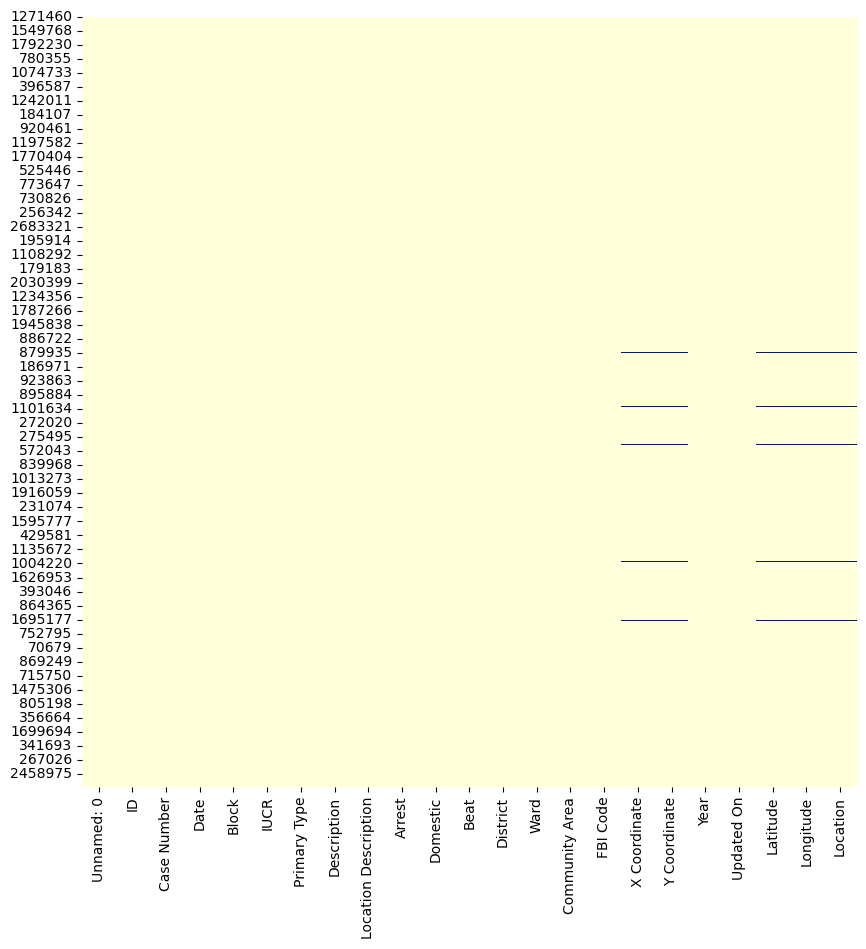

In [32]:
sample_df = chicago_df.sample(10000)

plt.figure(figsize=(10,10))
sns.heatmap(sample_df.isnull(), cbar=False, cmap='YlGnBu')

In [34]:
chicago_df.drop(['Unnamed: 0', 'Case Number', 'Case Number', 'IUCR', 'X Coordinate', 'Y Coordinate','Updated On','Year', 'FBI Code', 'Beat','Ward','Community Area', 'Location', 'District', 'Latitude' , 'Longitude'], inplace=True, axis=1)

In [38]:
chicago_df.Date = pd.to_datetime(chicago_df.Date,format = '%m/%d/%Y %I:%M:%S %p')

In [39]:
chicago_df.Date

0         2006-04-02 13:00:00
1         2006-02-26 13:40:48
2         2006-01-08 23:16:00
3         2006-04-05 18:45:00
4         2006-02-17 21:03:14
                  ...        
1456709   2016-05-03 23:33:00
1456710   2016-05-03 23:30:00
1456711   2016-05-03 00:15:00
1456712   2016-05-03 21:07:00
1456713   2016-05-03 23:38:00
Name: Date, Length: 6017767, dtype: datetime64[ns]

In [50]:
chicago_df.index = pd.DatetimeIndex(chicago_df.Date)

In [51]:
order_data = chicago_df['Primary Type'].value_counts().iloc[:15].index

<Axes: xlabel='count', ylabel='Primary Type'>

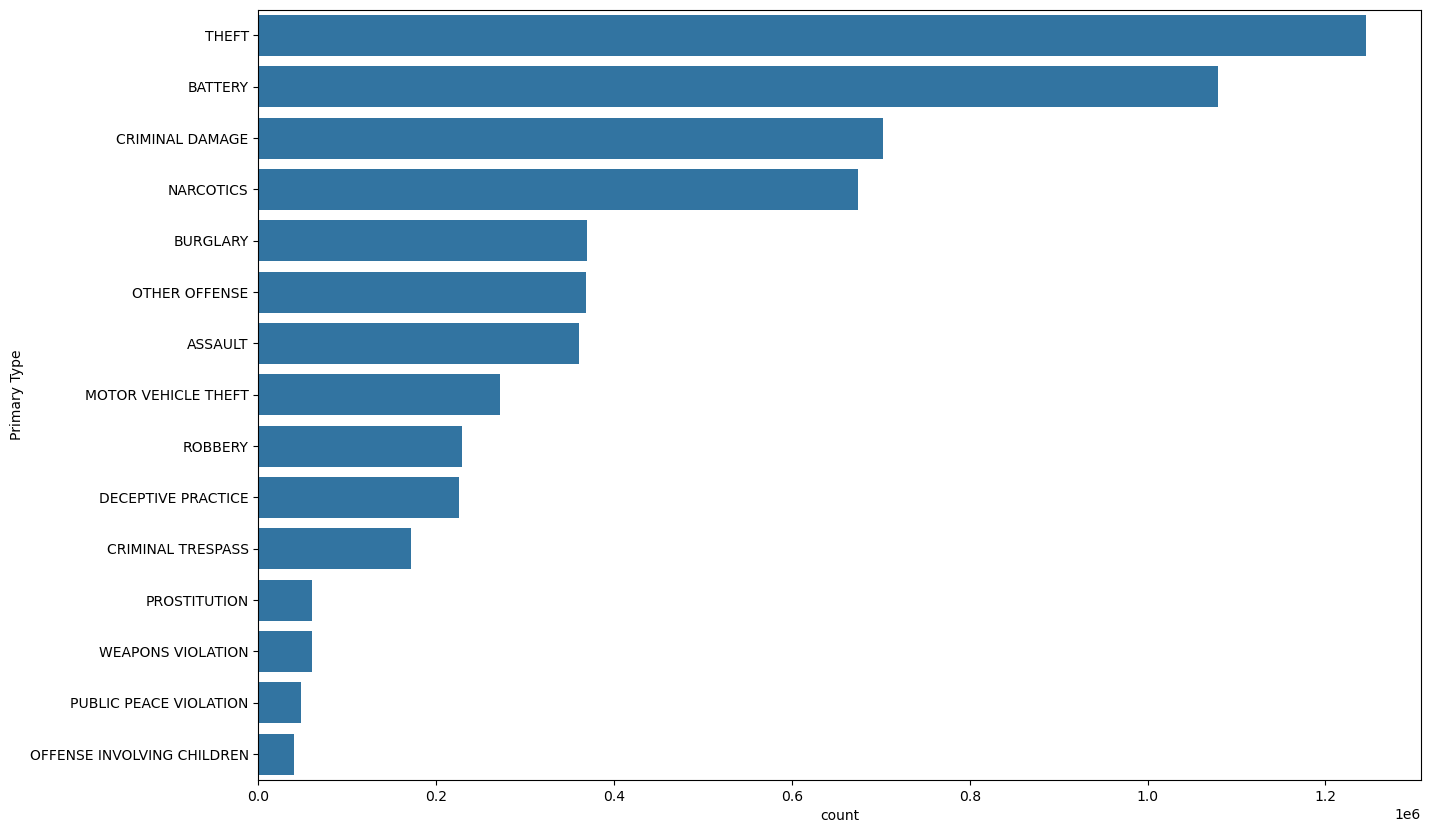

In [52]:
plt.figure(figsize = (15,10))
sns.countplot(y = 'Primary Type', data = chicago_df.reset_index(drop=True),order = order_data)

<Axes: xlabel='count', ylabel='Location Description'>

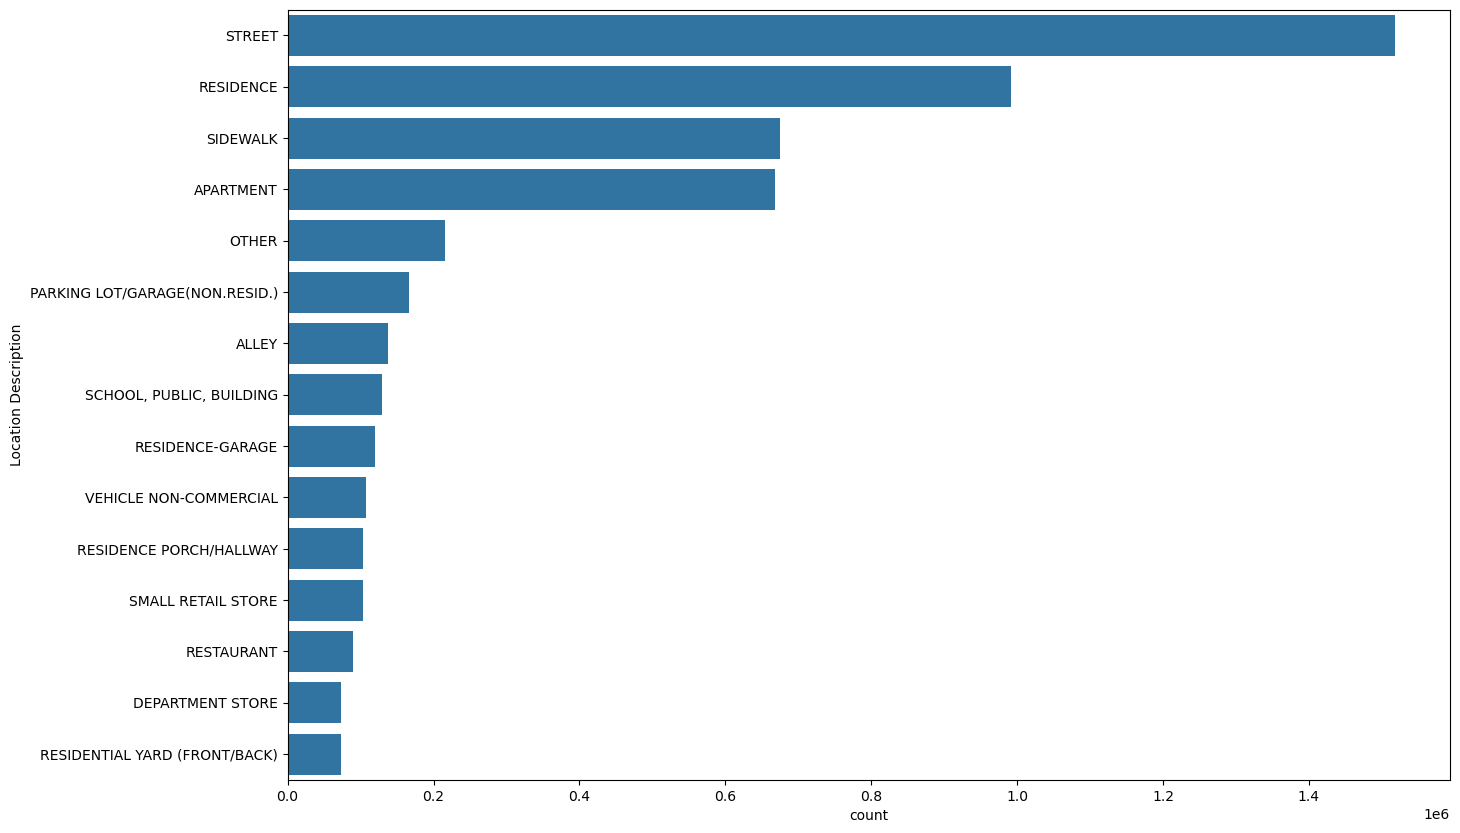

In [53]:
order_data_1 = chicago_df['Location Description'].value_counts().iloc[:15].index
plt.figure(figsize=(15,10))
sns.countplot(y = 'Location Description', data = chicago_df.reset_index(drop = True), order = order_data_1)

In [62]:
year_plotting = chicago_df.resample('Y').size()
month_plotting = chicago_df.resample('m').size()
quarter_plotting = chicago_df.resample('Q').size()

C:\Users\User\AppData\Local\Temp\ipykernel_16100\3232814063.py:1: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  year_plotting = chicago_df.resample('Y').size()
C:\Users\User\AppData\Local\Temp\ipykernel_16100\3232814063.py:2: FutureWarning: 'm' is deprecated and will be removed in a future version, please use 'ME' instead.
  month_plotting = chicago_df.resample('m').size()
C:\Users\User\AppData\Local\Temp\ipykernel_16100\3232814063.py:3: FutureWarning: 'Q' is deprecated and will be removed in a future version, please use 'QE' instead.
  quarter_plotting = chicago_df.resample('Q').size()


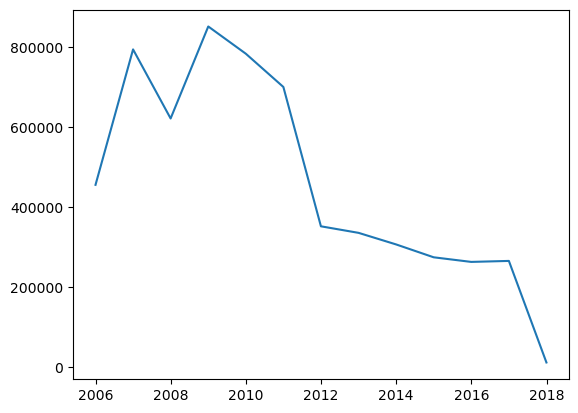

In [63]:
plt.plot(year_plotting)
plt.tittle = ('Crime rate over years')
plt.xlable = ('Years')
plt.ylable = ('nb of crimes')

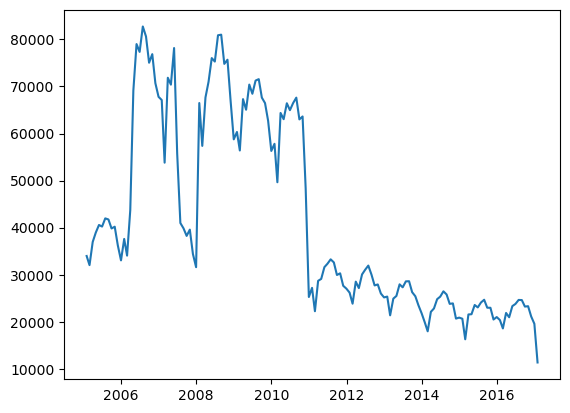

In [64]:
plt.plot(month_plotting)
plt.tittle = ('Crime rate over years')
plt.xlable = ('Years')
plt.ylable = ('nb of crimes')

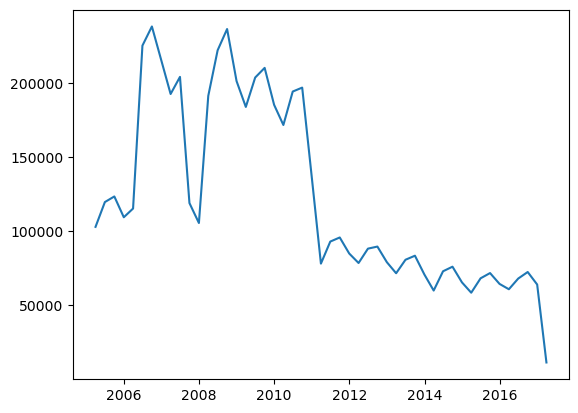

In [65]:
plt.plot(quarter_plotting)
plt.tittle = ('Crime rate over years')
plt.xlable = ('Years')
plt.ylable = ('nb of crimes')

In [66]:
#Now preparing the data

In [67]:
chicago_prophet = chicago_df.resample('M').size().reset_index()

C:\Users\User\AppData\Local\Temp\ipykernel_16100\1392186512.py:1: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  chicago_prophet = chicago_df.resample('M').size().reset_index()


In [68]:
chicago_prophet

,Date,0
0,2005-01-31,33983
1,2005-02-28,32042
2,2005-03-31,36970
3,2005-04-30,38963
4,2005-05-31,40572
...,...,...
140,2016-09-30,23235
141,2016-10-31,23314
142,2016-11-30,21140
143,2016-12-31,19580


In [69]:
chicago_prophet.columns = ['Date','Crime Count']

In [70]:
chicago_prophet

,Date,Crime Count
0,2005-01-31,33983
1,2005-02-28,32042
2,2005-03-31,36970
3,2005-04-30,38963
4,2005-05-31,40572
...,...,...
140,2016-09-30,23235
141,2016-10-31,23314
142,2016-11-30,21140
143,2016-12-31,19580


In [73]:
chicago_prophet_df_final =chicago_prophet.rename(columns={'Date':'ds','Crime Count':'y'})

In [74]:
chicago_prophet_df_final.columns = ['ds','y']

In [75]:
chicago_prophet_df_final

,ds,y
0,2005-01-31,33983
1,2005-02-28,32042
2,2005-03-31,36970
3,2005-04-30,38963
4,2005-05-31,40572
...,...,...
140,2016-09-30,23235
141,2016-10-31,23314
142,2016-11-30,21140
143,2016-12-31,19580


In [76]:
#Final steps, making the prediction

In [78]:
model = Prophet()
model.fit(chicago_prophet_df_final)

14:52:07 - cmdstanpy - INFO - Chain [1] start processing
14:52:07 - cmdstanpy - INFO - Chain [1] done processing


In [82]:
future = model.make_future_dataframe(periods = 365*2)
forecast = model.predict(future)
forecast

,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,additive_terms,additive_terms_lower,additive_terms_upper,yearly,yearly_lower,yearly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
0,2005-01-31,60454.822242,38994.971831,73682.409150,60454.822242,60454.822242,-4762.396041,-4762.396041,-4762.396041,-4762.396041,-4762.396041,-4762.396041,0.0,0.0,0.0,55692.426201
1,2005-02-28,60322.419701,33333.912535,68141.249426,60322.419701,60322.419701,-9500.521164,-9500.521164,-9500.521164,-9500.521164,-9500.521164,-9500.521164,0.0,0.0,0.0,50821.898537
2,2005-03-31,60175.831174,43312.974553,75568.583613,60175.831174,60175.831174,-1224.152569,-1224.152569,-1224.152569,-1224.152569,-1224.152569,-1224.152569,0.0,0.0,0.0,58951.678604
3,2005-04-30,60033.971308,43832.002737,77565.761258,60033.971308,60033.971308,1182.829447,1182.829447,1182.829447,1182.829447,1182.829447,1182.829447,0.0,0.0,0.0,61216.800755
4,2005-05-31,59887.382780,47741.870679,82101.044911,59887.382780,59887.382780,5498.248024,5498.248024,5498.248024,5498.248024,5498.248024,5498.248024,0.0,0.0,0.0,65385.630804
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
870,2019-01-27,5335.065900,-15182.018222,15741.193625,4851.496812,5797.996912,-4991.570626,-4991.570626,-4991.570626,-4991.570626,-4991.570626,-4991.570626,0.0,0.0,0.0,343.495273
871,2019-01-28,5321.999279,-16706.383155,17690.663314,4837.093698,5785.079855,-4936.454794,-4936.454794,-4936.454794,-4936.454794,-4936.454794,-4936.454794,0.0,0.0,0.0,385.544485
872,2019-01-29,5308.932657,-16797.259255,17307.226922,4823.078888,5772.131689,-4881.352760,-4881.352760,-4881.352760,-4881.352760,-4881.352760,-4881.352760,0.0,0.0,0.0,427.579898
873,2019-01-30,5295.866036,-16075.817853,16879.800794,4809.124288,5759.183524,-4829.018765,-4829.018765,-4829.018765,-4829.018765,-4829.018765,-4829.018765,0.0,0.0,0.0,466.847271


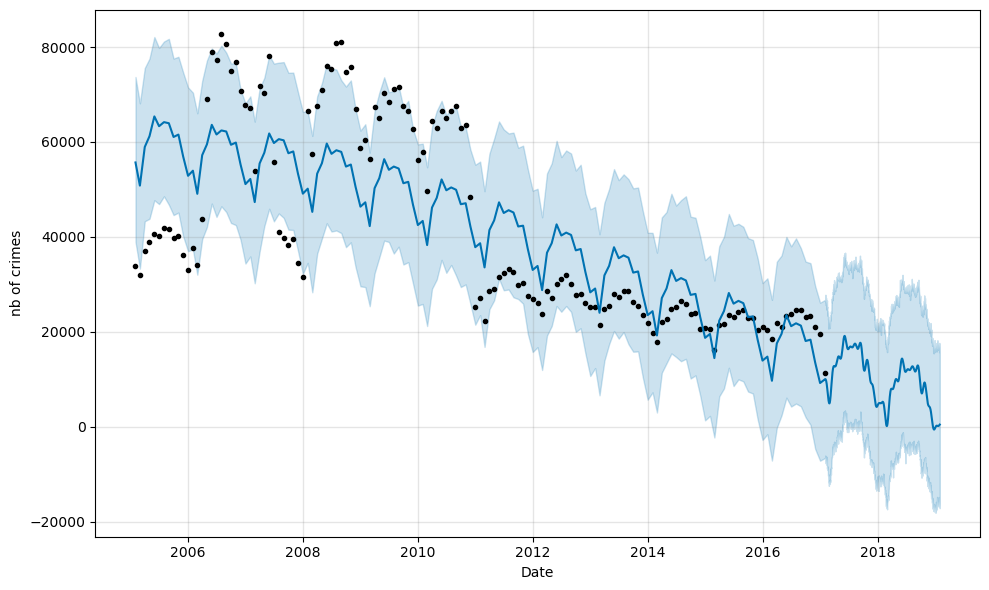

In [83]:
figure = model.plot(forecast, xlabel = 'Date', ylabel = 'nb of crimes')

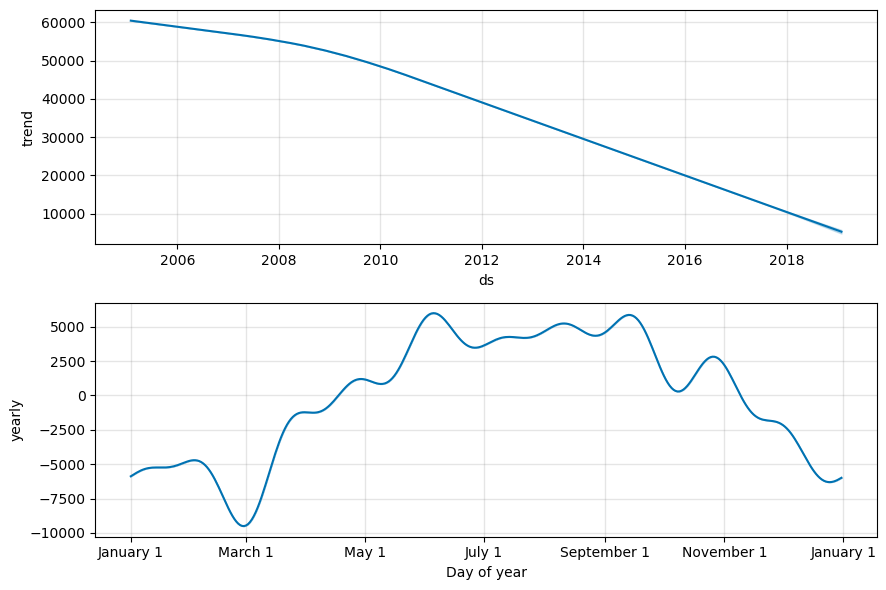

In [84]:
figure3 = model.plot_components(forecast)